# visit[1-4] weekly + prev MFIS for each visit

In [89]:
from src.patient_data_dispatcher import PatientDataDispatcher
from src.model import ModelConfig
from src.core.enums import MileStone, PatientDataType, DataFrequency
from src.core.normaliser import Normaliser
from sklearn.preprocessing import MinMaxScaler
from src.train import LSTMRegressionXV
from src.core.data_transforms import Transform


import torch


In [90]:
K_FOLDS = 5
N_VISITS = 4

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [110]:
from torch.nn import HuberLoss, CrossEntropyLoss, MSELoss
from torch.optim import Adam

config = ModelConfig(
    name="lstm_regression",
    model_type="LSTM",
    input_size=25,
    hidden_size=128,
    num_layers=2,
    output_size=1,
    batch_size=16,
    epochs=50,
    optimiser=Adam,
    loss_fn=MSELoss(),
    learning_rate=5e-4,
)

config.notes = "None"

In [93]:
dmo_features = [
    "wb_all_sum",
    "walkdur_all_sum",
    "wbsteps_all_sum",
    "wbdur_all_avg",
    "wbdur_all_p90",
    "wbdur_all_var",
    "cadence_all_avg",
    "strdur_all_avg",
    "cadence_all_var",
    "strdur_all_var",
    "ws_1030_avg",
    "strlen_1030_avg",
    "wb_10_sum",
    "ws_10_p90",
    "wb_30_sum",
    "ws_30_avg",
    "strlen_30_avg",
    "cadence_30_avg",
    "strdur_30_avg",
    "ws_30_p90",
    "cadence_30_p90",
    "ws_30_var",
    "strlen_30_var",
    "wb_60_sum",
]

In [94]:
# dmo_features = [
#     "cadence_30_p90_d",
#     "cadence_30_avg_d",
#     "ws_30_p90_d",
#     "strlen_1030_avg_d",
#     "cadence_all_avg_d",
# ]

In [95]:
# dmo_features = [
#     "cadence_30_p90_d",
#     "cadence_30_avg_d",
#     "ws_30_p90_d",
#     "strlen_1030_avg_d",
#     "cadence_all_avg_d",
# ]

In [96]:
pdd = PatientDataDispatcher(
    "config/config.yaml",
    dmo_features,
    MileStone.ALL,
    data_frequency=DataFrequency.DAILY,
    physical_subset=True,
    #static_features=static_features
)
ids = list(set(pdd.metadata["Local.Participant"].to_list()))
dmo_data, dmo_labels = pdd.get_patient_data(PatientDataType.MILESTONE, ids=ids)

In [97]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# perform impute on a visit by visit basis, as some visits are completely missing
imputer = IterativeImputer(missing_values=-1, tol=1e-2, keep_empty_features=True)
patients, visits, features, days = dmo_data.shape

for p in range(patients):
    for v in range(visits):
        visit_data = dmo_data[p, v]

        if (visit_data == -1).all():
            continue

        dmo_data[p, v] = torch.from_numpy(imputer.fit_transform(visit_data)).to(dtype=torch.float64)

/home/gwilym-rutherford/Documents/Year 3 Tuos/dissertation/Workspace/Experiment 1/.venv/lib/python3.13/site-packages/sklearn/impute/_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [98]:
dmo_data, dmo_labels = Transform.get_patient_visits(dmo_data, dmo_labels, n_visits=N_VISITS)

In [99]:
# remove patients that don't have a full dataset
patient_indexs = []
patient, visit, days, features = dmo_data.shape
for p in range(patient):
    all_visits = True
    for v in range(visit):
        data = dmo_data[p, v]
        label = dmo_labels[p, v]
        if (data == -1.0).any() or label == -1.0:
            all_visits = False

    if all_visits:
        patient_indexs.append(p)

fatigue_value = dmo_labels[patient_indexs]
dmo_data = dmo_data[patient_indexs]

In [100]:
dmo_data = dmo_data.mean(axis=2)
dmo_data.shape

torch.Size([428, 4, 24])

In [101]:
# Min max normalise all fatigue values
physical_subset_max = 36
fatigue_value = fatigue_value / physical_subset_max

In [102]:
fatigue_input = fatigue_value[:, :-1, :]

fatigue_label = fatigue_value[:, -1, :]
print(fatigue_input.shape)
print(fatigue_label.shape)

torch.Size([428, 3, 1])
torch.Size([428, 1])


In [103]:
fatigue_input.shape

torch.Size([428, 3, 1])

In [104]:
patients, visits, _ = dmo_data.shape
fatigue_values_to_concat = torch.zeros(patients, 1, 1)
fatigue_values_to_concat = torch.cat((fatigue_values_to_concat, fatigue_input), dim=1)
fatigue_values_to_concat.shape

torch.Size([428, 4, 1])

In [105]:
fatigue_values_to_concat[0]

tensor([[0.0000],
        [0.1944],
        [0.4167],
        [0.6389]])

In [106]:
dmo_data.shape

torch.Size([428, 4, 24])

In [107]:
dmo_data = torch.cat((dmo_data, fatigue_values_to_concat), dim=2)
dmo_data = dmo_data[:, :-1, :]
dmo_data.shape

torch.Size([428, 3, 25])

In [108]:
dmo_labels = fatigue_value[:, -1, :]
dmo_labels.shape

torch.Size([428, 1])

In [111]:
xv_trainer = LSTMRegressionXV(dmo_data, dmo_labels, config, device, k=K_FOLDS)
prediction, actual = xv_trainer.train_cross_validation(
    pred_transform=lambda x: x[:, -1, :]
)

Testing loss: 0.026809363315502804
Testing loss: 0.0429901322349906
Testing loss: 0.03820482734590769
Testing loss: 0.0336828955138723
Testing loss: 0.03959855095793804


In [112]:
prediction = torch.concatenate(prediction).flatten()
prediction = (prediction * physical_subset_max).flatten()
prediction.shape

torch.Size([428])

In [113]:
actual = torch.concatenate(actual).flatten()
actual = (actual * physical_subset_max).flatten()
actual.shape

torch.Size([428])

In [114]:
print(xv_trainer.R2_values)

[0.5078833103179932, 0.34047412872314453, 0.33222389221191406, 0.31610769033432007, 0.3506459593772888]


All metrics: {'accuracy': 0.009345794392523364, 'Mean Squared Error': 44.193214416503906, 'Mean Absolute Error': 5.131727695465088, 'R^2': 0.3755648732185364}


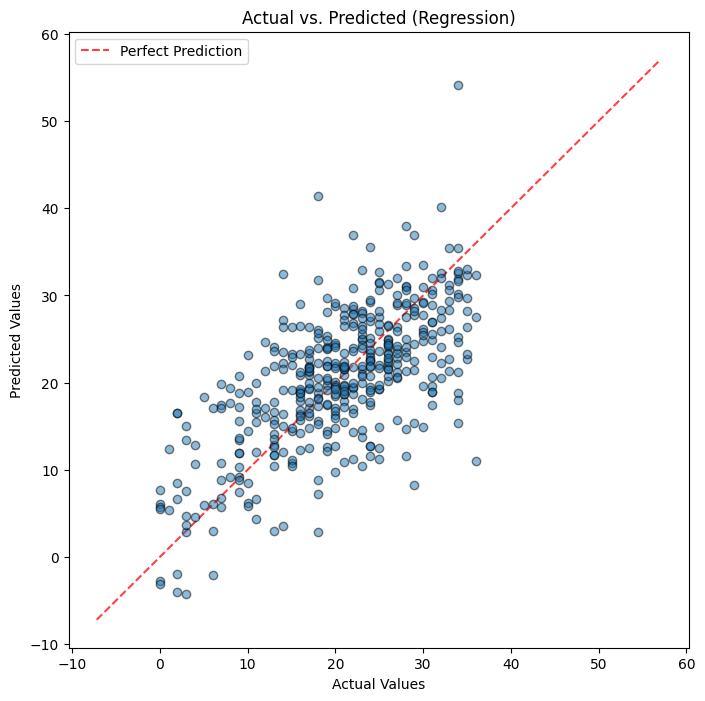

In [115]:
from src.evaluation import Evaluation

evaluation = Evaluation(prediction, actual)
print(f"All metrics: {evaluation.compute_all_metrics()}")
evaluation.evaluation_plot().show()
